<a href="https://colab.research.google.com/github/angelicasilvacorredor/Analysis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?










---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [ ]:
# mostrar primeras filas
plans.head()
users.head()
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)



plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---



## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.



In [ ]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

In [ ]:

Diagnóstico de datos faltantes

Dataset users:
- city presenta 11.7% de valores ausentes. Es un nivel intermedio, por lo que conviene revisar su origen y considerar rellenarlo con una categoría como "No especificado" si se requiere para análisis por ubicación.
- churn_date tiene 88.3% de valores faltantes. Esto probablemente ocurre porque solo se registra cuando un cliente cancela el servicio. Se recomienda conservar la columna y utilizarla para identificar clientes activos e inactivos.

Dataset usage:
- date muestra 0.1% de valores faltantes. Es un porcentaje muy bajo, por lo que esos registros pueden eliminarse o corregirse fácilmente.
- duration tiene 55.1% de ausencias. Es posible que esta variable solo aplique a eventos de llamadas, por lo que se debe validar con la columna type.
- length presenta 44.7% de nulos. Probablemente corresponde solo a mensajes, así que también conviene revisarlo junto con type.

Recomendación general:
Los valores faltantes en duration y length parecen depender del tipo de actividad registrada, por lo que no necesariamente son errores. Lo ideal es separar el análisis entre llamadas y mensajes.

SyntaxError: invalid syntax (2680124324.py, line 1)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [ ]:
- La columna user_id funciona como identificador único de cada cliente. Los valores se observan numéricos y positivos, por lo que no se aprecian inconsistencias a simple vista.
Aun así, sería conveniente verificar que no existan registros repetidos.

- La columna age muestra la edad de los usuarios. Se recomienda revisar si aparecen valores poco creíbles, como números negativos o edades excesivamente altas.
Si se detectan casos así, lo ideal sería corregirlos o registrarlos como valores faltantes.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [ ]:
- Las columnas id y user_id funcionan como identificadores numéricos dentro del dataset. Los valores se ven positivos y ordenados dentro de un rango esperado,
por lo que no se observan problemas claros a simple vista. Aun así, sería buena idea revisar si hay registros repetidos, sobre todo en la columna id.

- Las columnas duration y length muestran la duración de llamadas y el tamaño de los mensajes. Aparecen valores en 0, lo que podría significar actividad sin consumo,
errores en el registro o datos incompletos. También hay valores bastante altos, por lo que sería útil analizar si corresponden a casos reales o a valores atípicos.

In [ ]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()



city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` ...
- La columna `plan` ...

In [ ]:


# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  


- ¿En qué columnas se encontraron valores inválidos o sentinels? Después de revisar la información, los principales posibles valores inválidos o sentinels se observan en las columnas city, age, duration y length. En la columna city aparecen valores nulos (NaN) y también el símbolo "?", lo que normalmente indica datos faltantes o errores durante la captura. La columna age también requiere atención, ya que podrían existir edades poco creíbles o fuera de un rango razonable. Por otro lado, en duration y length se observan valores iguales a 0, además de algunos registros bastante altos, por lo que conviene revisarlos con mayor detalle.
- ¿Qué acción tomaría? En city, lo más recomendable sería convertir el símbolo "?" en valor nulo y después decidir si esos registros deben completarse o mantenerse como faltantes. En age, revisaría cualquier edad fuera de un rango lógico y, en caso necesario, la corregiría o la marcaría como dato ausente. En duration y length, analizaría los valores en 0 para confirmar si representan actividad real sin consumo o si corresponden a errores del sistema. También revisaría los valores extremos para validar si son casos reales o datos atípicos. Finalmente, las columnas plan y type no muestran inconsistencias evidentes, por lo que en principio no sería necesario realizar cambios inmediatos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificar el cambio
print(users['reg_date'].dtype)
print(users['reg_date'].isna().sum(), "nulos tras conversión")

datetime64[ns]
0 nulos tras conversión


In [ ]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Verificar el cambio
print(usage['date'].dtype)
print(usage['date'].isna().sum(), "nulos tras conversión")

datetime64[ns]
50 nulos tras conversión


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Al revisar los años presentes en reg_date, los datos se distribuyen de forma razonable entre 2022 y 2024. Sin embargo, aparecen 40 registros fechados en 2026, un año que aún no debería tener datos registrados. Esto sugiere que hubo errores al momento de ingresar la información.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

A diferencia de reg_date, aquí no hay sorpresas: toda la actividad registrada ocurrió en 2024, que es exactamente lo que se esperaba. Los 50 valores faltantes ya eran conocidos desde la revisión de nulos y simplemente no participan en este conteo.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se encontraron 40 fechas futuras (2026) en reg_date. En usage['date'] no hay anomalías. La acción recomendada es tratarlos como NaT — son errores de captura sin forma de corregirse y conservarlos afectaría cualquier análisis basado en tiempo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage para duration
print("Proporción de nulos en duration según type")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

print("\nConteo de nulos en duration según type")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))


Proporción de nulos en duration según type
type
call    0.000000
text    0.999276
Name: duration, dtype: float64

Conteo de nulos en duration según type
type
call        0
text    22076
Name: duration, dtype: int64


In [ ]:
# Verificación MAR en usage para length
print("\nProporción de nulos en length según type")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

print("\nConteo de nulos en length según type")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))



Proporción de nulos en length según type
type
call    0.99933
text    0.00000
Name: length, dtype: float64

Conteo de nulos en length según type
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

El patrón observado es bastante claro: la columna duration solo contiene información cuando el registro corresponde a una llamada, mientras que length solo tiene valores cuando se trata de mensajes de texto.
Esto indica que cada variable aplica únicamente a su tipo de evento, por lo que los valores nulos en la categoría opuesta son normales y esperados. No se consideran errores de calidad de datos.
Por esta razón, no tendría sentido reemplazar esos nulos con promedios, ceros u otros valores. Lo más adecuado es conservarlos como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)   # conocer total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # conocer total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe().round(2))


           age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.00        3999.00        3999.00               3999.00
mean     48.14           5.52           4.48                 23.32
std      17.69           2.36           2.14                 18.17
min      18.00           0.00           0.00                  0.00
25%      33.00           4.00           3.00                 11.12
50%      48.00           5.00           4.00                 19.78
75%      63.00           7.00           6.00                 31.42
max      79.00          17.00          15.00                155.69


A primera vista, los usuarios tienen un perfil de edad amplio — entre 18 y 79 años con una media de 48 — lo que refleja una base madura y heterogénea. El comportamiento de uso promedio es moderado: poco más de 5 mensajes y 4 llamadas por usuario. Sin embargo, los máximos cuentan otra historia — hay usuarios que envían hasta 17 mensajes, realizan 15 llamadas y acumulan más de 155 minutos, muy por encima de la mediana de 19.78. Esto sugiere que conviven dos perfiles: usuarios de consumo moderado y usuarios de alto consumo, algo que los histogramas del siguiente paso deberían confirmar.

In [ ]:
# Distribución porcentual del tipo de plan
print(((user_profile['plan'].value_counts(normalize=True) * 100).round(2)).astype(str) + "%")

Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


A primera vista, los usuarios presentan un rango de edad amplio, entre 18 y 79 años, con una media cercana a 48 años, lo que refleja una base diversa y madura. El nivel de uso promedio es moderado: alrededor de 5 mensajes y 4 llamadas por usuario. Sin embargo, los valores máximos muestran una realidad distinta: algunos clientes envían hasta 17 mensajes, realizan 15 llamadas y acumulan más de 155 minutos de conversación, superando ampliamente la mediana de minutos de llamada (19.78 min). Esto sugiere la convivencia de al menos dos perfiles de consumo: usuarios de uso moderado y usuarios intensivos. Los histogramas del siguiente paso ayudarán a confirmar esta diferencia en la distribución. En cuanto a los planes, la base está claramente inclinada hacia el plan Básico con un 64.88%, mientras que el plan Premium concentra el 35.12%. Esta diferencia debe considerarse al comparar patrones de consumo y churn entre ambos grupos.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

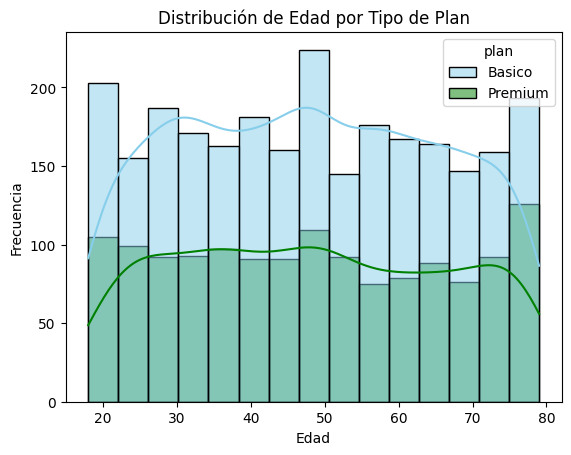

In [ ]:

# Histograma de Edad
sns.histplot(data=user_profile, x='age', hue='plan', kde=True, palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
La edad se distribuye de forma relativamente homogénea, sin un grupo dominante claramente marcado. El plan Básico aparece con mayor frecuencia en casi todos los rangos, lo cual es consistente con su mayor participación dentro de la base total. No se observa un patrón claro entre la edad del usuario y el tipo de plan contratado.

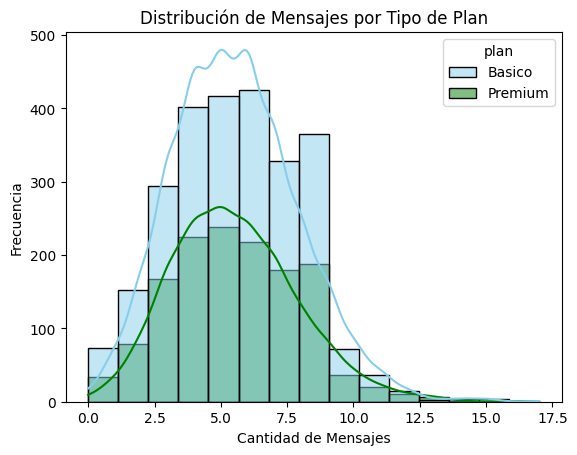

In [ ]:
# Histograma de Cantidad de Mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', kde=True, palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución de mensajes es cercana a una forma normal, con ligero sesgo a la derecha y mayor concentración entre 2 y 8 mensajes por usuario. Ambos planes muestran comportamientos similares, por lo que el tipo de plan no parece influir de manera importante en la cantidad de mensajes enviados.

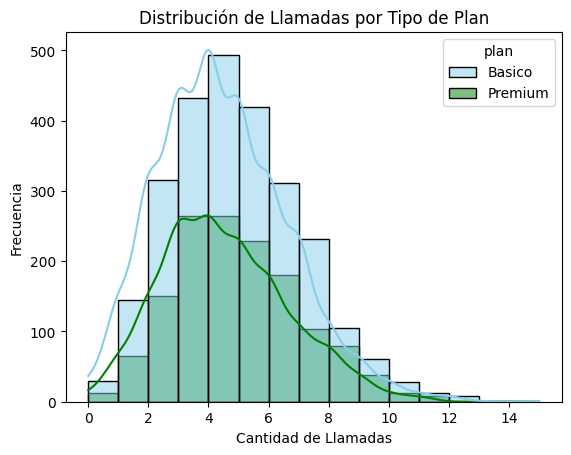

In [ ]:


# Histograma de Cantidad de Llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', kde=True, palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución de llamadas presenta sesgo a la derecha, con la mayoría de usuarios concentrados entre 2 y 7 llamadas. Ambos planes mantienen patrones similares, aunque el plan Básico muestra mayor frecuencia en los rangos bajos debido a su mayor cantidad de usuarios. No se observan diferencias relevantes según el tipo de plan.

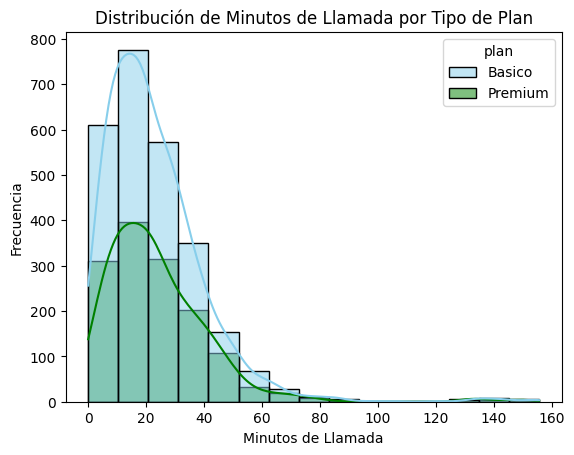

In [ ]:
# Histograma de Minutos de Llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', kde=True, palette=['skyblue', 'green'], bins=15)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución de minutos de llamada está fuertemente sesgada a la derecha. La mayoría de usuarios acumula entre 0 y 40 minutos, aunque existe una cola larga que alcanza aproximadamente 160 minutos. Esto confirma la presencia de usuarios con consumo elevado detectados en el resumen estadístico. Ambos planes presentan un comportamiento general similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

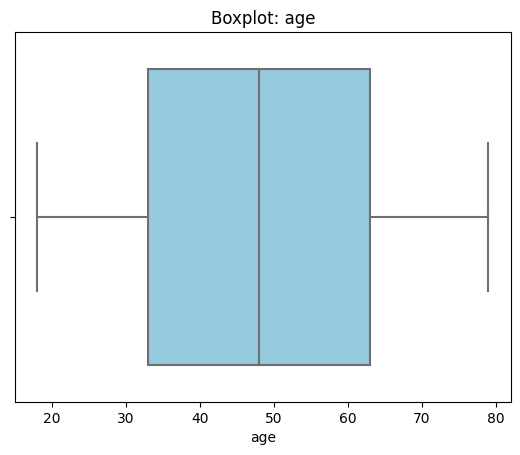

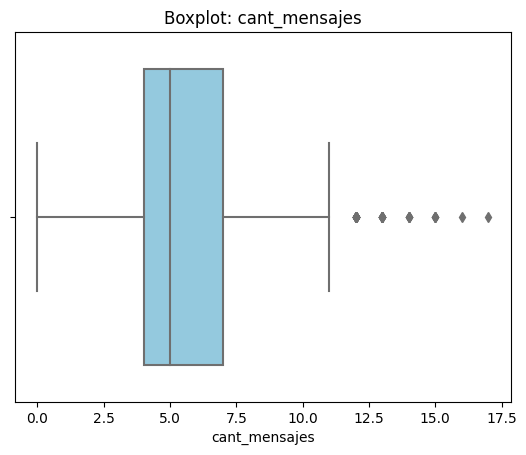

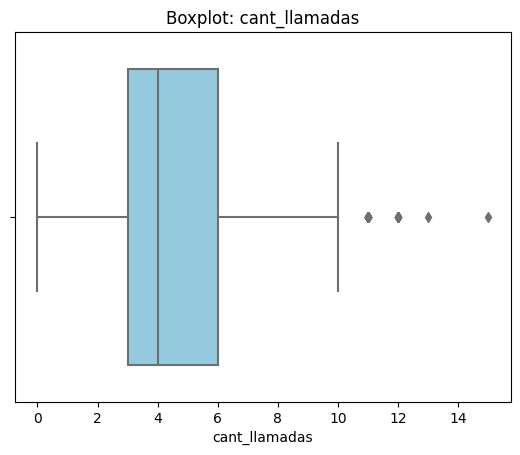

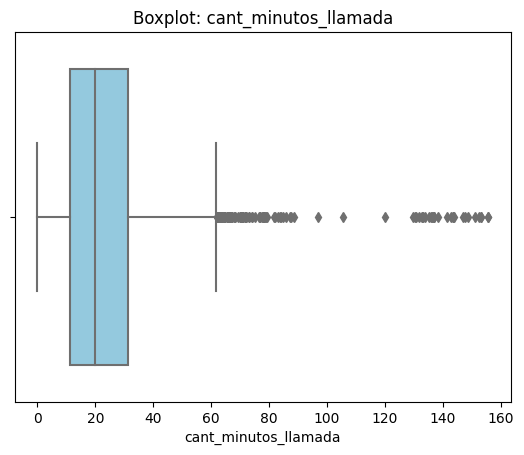

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:

- Age: no presenta outliers visibles. La distribución es relativamente simétrica y los valores se mantienen dentro de un rango esperado.

- cant_mensajes: presenta outliers hacia la derecha, con algunos usuarios que superan los 13 mensajes.

- cant_llamadas: presenta outliers hacia la derecha, con usuarios que registran más de 11 llamadas.

- cant_minutos_llamada: es la variable con mayor presencia de outliers. Muestra una cola extensa hacia la derecha que alcanza aproximadamente 160 minutos.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col} → Límite superior IQR: {limite_superior:.2f} | Máximo: {user_profile[col].max():.2f}")



cant_mensajes → Límite superior IQR: 11.50 | Máximo: 17.00
cant_llamadas → Límite superior IQR: 10.50 | Máximo: 15.00
cant_minutos_llamada → Límite superior IQR: 61.86 | Máximo: 155.69


In [ ]:

# Revisa los límites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.00,3999.00,3999.00
mean,5.52,4.48,23.32
std,2.36,2.14,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.12
50%,5.00,4.00,19.78
75%,7.00,6.00,31.42
max,17.00,15.00,155.69


💡Insights:
- cant_mensajes:
Aunque algunos usuarios superan el límite IQR de 11.50 mensajes y alcanzan hasta 17, estos valores siguen siendo totalmente plausibles en un contexto real. Enviar 17 mensajes en un periodo no indica error, sino mayor actividad. Se decide mantenerlos.


- cant_llamadas:
El límite IQR se ubica en 10.50 llamadas, con un máximo observado de 15. Aunque exceden el umbral estadístico, no representan un comportamiento imposible ni sospechoso. Corresponden a usuarios con mayor uso telefónico. Eliminarlos podría sesgar el análisis, por lo que se conservan.


- cant_minutos_llamada:
Es la variable con mayor diferencia entre el límite IQR (61.86 min) y el máximo observado (155.69 min). Aun así, acumular ese nivel de minutos es razonable para usuarios intensivos o con llamadas prolongadas. Excluirlos implicaría perder información valiosa sobre segmentos de alto consumo. Se decide mantenerlos.

---

#
# 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)



In [ ]:

# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

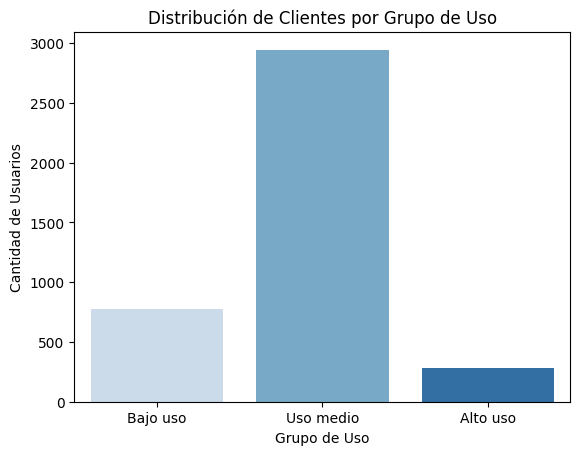

In [ ]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',
              palette='Blues',
              order=['Bajo uso', 'Uso medio', 'Alto uso'])

plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

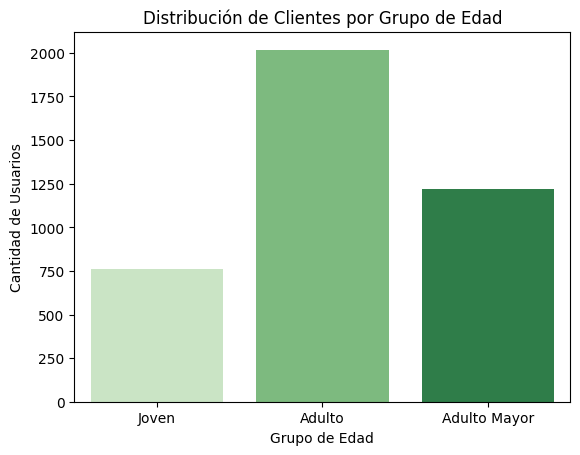

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              palette='Greens',
              order=['Joven', 'Adulto', 'Adulto Mayor'])

plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ Problemas detectados en los datos

La columna reg_date contenía 40 registros con año 2026, fechas imposibles que representan aproximadamente 1% de los usuarios. Estos valores fueron marcados como nulos.

En city se detectaron 96 registros con el valor "?", equivalentes al 2.4% de la base. Fueron reemplazados por pd.NA.

La columna churn_date presentó 88.35% de valores nulos, lo cual es completamente esperado, ya que solo los usuarios que cancelaron el servicio cuentan con una fecha registrada.

Los nulos en duration y length no corresponden a errores, sino a la naturaleza del dato: la duración no aplica a mensajes de texto y la longitud no aplica a llamadas.


🔍 Segmentos por Edad

El grupo más numeroso corresponde a los Adultos (30 a 59 años), seguido por los Adultos Mayores (60+), mientras que los Jóvenes (menores de 30) representan la menor proporción de la base.

No se observan diferencias relevantes entre los planes Básico y Premium dentro de los grupos etarios, ya que ambos se distribuyen de forma similar. Esto sugiere que la edad no sería el principal factor al momento de elegir un plan.

📊 Segmentos por Nivel de Uso

La mayoría de los clientes se concentra en el segmento de Uso medio (aprox. 2,900 usuarios), seguido por Bajo uso (alrededor de 750) y finalmente Alto uso (cerca de 300).

Aunque el grupo de Alto uso es el más pequeño, reúne a los clientes con mayor intensidad de consumo: más de 10 llamadas, más de 10 mensajes y niveles de minutos que pueden superar los 60 mensuales.

Esto lo convierte en un segmento estratégico por su potencial de ingresos y oportunidades de upselling.

➡️ Esto sugiere que...

La mayor parte de la base está formada por usuarios de consumo moderado, mientras que existe un grupo más pequeño, pero muy valioso, de clientes con uso intensivo.

Lo más interesante es que el plan Premium no siempre implica un mayor consumo. Hay usuarios del plan Básico con niveles de uso altos, así como clientes Premium con consumo bajo.

Esto indica que la oferta actual de planes no está completamente alineada con el comportamiento real de los usuarios, por lo que existe una oportunidad para ajustar la segmentación y diseñar opciones más adecuadas para cada perfil de cliente.


💡 Recomendaciones

El segmento de Uso medio, con casi 3,000 usuarios, representa el núcleo de la base de clientes. Conviene diseñar una oferta intermedia pensada para sus necesidades, evitando que el plan Básico resulte limitado o que el Premium se perciba excesivo.

Los usuarios de Alto uso son menos numerosos, pero concentran mayor consumo. Un plan específico para este grupo — con más minutos incluidos, beneficios adicionales o tarifas escalonadas — podría fortalecer la lealtad y aumentar ingresos.

Los Adultos Mayores conforman el segundo grupo más grande y podrían beneficiarse de planes más simples, comunicación clara y atención prioritaria. Mejorar su experiencia puede traducirse en mayor retención.

Finalmente, los problemas detectados en la calidad de datos, como fechas futuras y valores sentinel, muestran la necesidad de incorporar validaciones automáticas al momento de captura. Es una mejora simple con alto impacto en la confiabilidad de la información.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`